# Lab 3: Actor-Critic Methods — SOLUTION

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

**This notebook contains the complete solution. Do not share with students.**

In [11]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

from networks import ContinuousActorCritic, SACActor, SACCritic
from utils import compute_gae, RolloutBuffer, ReplayBuffer, plot_a2c_results, plot_sac_results, plot_comparison, record_agent_video, smooth

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cuda
Experiments directory: /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments
Setup complete!


---

# Part A — Implementation

---

## A2C Agent — Complete Solution

In [12]:
class A2CAgent:
    """Advantage Actor-Critic (A2C) agent for continuous control — SOLUTION."""

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        n_steps: int = 2048,
        batch_size: int = 64,
        vf_coef: float = 0.5,
        ent_coef: float = 0.0,
        max_grad_norm: float = 0.5,
        seed: int = 42,
    ):
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.n_steps       = n_steps
        self.batch_size    = batch_size
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.max_grad_norm = max_grad_norm

        # SOLUTION: initialize components
        self.network   = ContinuousActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.buffer    = RolloutBuffer(n_steps, state_dim, action_dim)

    @torch.no_grad()
    def collect_rollout(self, env, obs):
        """Collect n_steps transitions and return (obs, last_value, episode_rewards)."""
        self.buffer.clear()
        episode_rewards   = []
        current_ep_reward = 0.0
        last_done         = False

        for _ in range(self.n_steps):
            state_t              = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob, _, value = self.network.get_action(state_t)
            action_np    = action.cpu().numpy().flatten()
            log_prob_val = log_prob.item()
            value_val    = value.item()

            next_obs, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated

            self.buffer.store(obs, action_np, reward, done, log_prob_val, value_val)

            current_ep_reward += reward
            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                next_obs, _ = env.reset()

            obs       = next_obs
            last_done = done

        # Bootstrap last value
        state_t    = torch.FloatTensor(obs).unsqueeze(0).to(device)
        last_value = self.network(state_t)[1].item()
        if last_done:
            last_value = 0.0

        return obs, last_value, episode_rewards

    def update(self):
        """One A2C gradient update over the full rollout (single gradient step)."""
        # Build full-rollout tensors
        states_t     = torch.FloatTensor(np.array(self.buffer.states)).to(device)
        actions_t    = torch.FloatTensor(np.array(self.buffer.actions)).to(device)
        advantages_t = torch.FloatTensor(self.buffer.advantages).to(device)
        returns_t    = torch.FloatTensor(self.buffer.returns).to(device)

        # Normalize advantages over the full rollout
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        # Re-evaluate actions under current policy
        _, log_probs, entropy, values = self.network.get_action(states_t, actions_t)

        policy_loss  = -(log_probs * advantages_t).mean()
        value_loss   = F.mse_loss(values.squeeze(-1), returns_t)
        entropy_loss = -entropy.mean()
        total_loss   = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
        self.optimizer.step()

        return {
            'policy_loss': policy_loss.item(),
            'value_loss':  value_loss.item(),
            'entropy':     entropy.mean().item(),
        }

print("A2CAgent class defined (SOLUTION)")

A2CAgent class defined (SOLUTION)


In [13]:
def train_a2c(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 1_000_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 10,
    **agent_kwargs,
):
    """Train an A2C agent — SOLUTION."""
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    agent      = A2CAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    policy_losses     = []
    value_losses      = []
    global_step       = 0
    update_num        = 0

    obs, _ = env.reset(seed=seed)

    while global_step < total_timesteps:
        # Collect rollout
        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
        global_step += agent.n_steps

        # Compute GAE advantages + value targets
        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)

        # Gradient update
        metrics    = agent.update()
        update_num += 1

        # Record episode rewards
        for r in ep_rewards:
            episode_rewards.append(r)
            episode_timesteps.append(global_step)

        policy_losses.append(metrics['policy_loss'])
        value_losses.append(metrics['value_loss'])

        if update_num % log_interval == 0:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            print(f"Update {update_num:4d} | Steps {global_step:>9,} | "
                  f"Avg Reward (10 ep): {avg_reward:7.1f} | "
                  f"Policy Loss: {metrics['policy_loss']:7.4f} | "
                  f"Value Loss: {metrics['value_loss']:7.4f}")

        if solve_threshold and len(episode_rewards) >= 10:
            if np.mean(episode_rewards[-10:]) >= solve_threshold:
                print(f"Solved at step {global_step:,}! "
                      f"Avg reward (10 ep): {np.mean(episode_rewards[-10:]):.1f}")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'policy_losses':     policy_losses,
        'value_losses':      value_losses,
        'agent':             agent,
    }

print("train_a2c defined (SOLUTION)")

train_a2c defined (SOLUTION)


## SAC Agent — Complete Solution

In [14]:
class SACAgent:
    """Soft Actor-Critic (SAC) agent for continuous control — SOLUTION."""

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        tau: float = 0.005,
        alpha: float = 0.2,
        autotune_alpha: bool = True,
        target_entropy: float = None,
        buffer_size: int = 1_000_000,
        batch_size: int = 256,
        learning_starts: int = 5000,
        train_frequency: int = 1,
        seed: int = 42,
    ):
        self.gamma           = gamma
        self.tau             = tau
        self.batch_size      = batch_size
        self.learning_starts = learning_starts
        self.train_frequency = train_frequency
        self.autotune_alpha  = autotune_alpha

        # SOLUTION: networks
        self.actor         = SACActor(state_dim, action_dim).to(device)
        self.critic        = SACCritic(state_dim, action_dim).to(device)
        self.critic_target = SACCritic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_target.eval()

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.replay_buffer    = ReplayBuffer(buffer_size, state_dim, action_dim, seed)

        # SOLUTION: entropy temperature
        if autotune_alpha:
            self.target_entropy  = float(target_entropy) if target_entropy is not None else -action_dim
            self.log_alpha       = torch.zeros(1, requires_grad=True, device=device)
            self.alpha           = self.log_alpha.exp().item()
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        else:
            self.alpha = alpha

    def select_action(self, state, deterministic=False):
        """Select an action (stochastic or deterministic)."""
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            if deterministic:
                mean, _  = self.actor(state_t)
                action   = torch.tanh(mean)
            else:
                action, _ = self.actor.get_action(state_t)
        return action.cpu().numpy().flatten()

    def update(self):
        """One full SAC gradient update (critic + actor + temperature + soft target)."""
        # Step 1: Sample batch
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states      = states.to(device)
        actions     = actions.to(device)
        rewards     = rewards.to(device)
        next_states = next_states.to(device)
        dones       = dones.to(device)

        # Step 2: Critic update
        with torch.no_grad():
            next_actions, next_log_pi = self.actor.get_action(next_states)
            q1_next, q2_next          = self.critic_target(next_states, next_actions)
            min_q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_pi.unsqueeze(-1)
            y          = rewards + self.gamma * (1.0 - dones) * min_q_next

        q1, q2      = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Step 3: Actor update
        new_actions, log_pi = self.actor.get_action(states)
        q1_pi, q2_pi        = self.critic(states, new_actions)
        min_q_pi            = torch.min(q1_pi, q2_pi)
        actor_loss          = (self.alpha * log_pi - min_q_pi.squeeze(-1)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Step 4: Temperature update (automatic tuning)
        alpha_loss = torch.tensor(0.0)
        if self.autotune_alpha:
            with torch.no_grad():
                _, log_pi = self.actor.get_action(states)
            alpha_loss = (-self.log_alpha.exp() * (log_pi + self.target_entropy)).mean()
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp().item()

        # Step 5: Soft target update (polyak averaging)
        for param, target_param in zip(self.critic.parameters(),
                                       self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        return {
            'critic_loss': critic_loss.item(),
            'actor_loss':  actor_loss.item(),
            'alpha_loss':  alpha_loss.item(),
            'alpha':       self.alpha,
        }

print("SACAgent class defined (SOLUTION)")

SACAgent class defined (SOLUTION)


In [15]:
def train_sac(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 300_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 5000,
    **agent_kwargs,
):
    """Train a SAC agent — SOLUTION."""
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    agent      = SACAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    critic_losses     = []
    actor_losses      = []
    alpha_history     = []

    obs, _ = env.reset(seed=seed)
    current_ep_reward = 0.0
    next_log          = log_interval

    for global_step in range(1, total_timesteps + 1):
        # Step 1: Random exploration warm-up or policy action
        if global_step < agent.learning_starts:
            action = env.action_space.sample()
        else:
            action = agent.select_action(obs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition (don't store terminal state as "done" if truncated only)
        real_done = float(terminated)
        agent.replay_buffer.push(obs, action, reward, next_obs, real_done)

        current_ep_reward += reward
        obs = next_obs

        if done:
            episode_rewards.append(current_ep_reward)
            episode_timesteps.append(global_step)
            current_ep_reward = 0.0
            obs, _ = env.reset()

        # Step 2: Gradient updates
        if (global_step >= agent.learning_starts and
                global_step % agent.train_frequency == 0):
            metrics = agent.update()
            critic_losses.append(metrics['critic_loss'])
            actor_losses.append(metrics['actor_loss'])
            alpha_history.append(metrics['alpha'])

        # Logging
        if global_step >= next_log:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            alpha_now  = agent.alpha
            print(f"Step {global_step:>9,} | Avg Reward (10 ep): {avg_reward:7.1f} | "
                  f"Alpha: {alpha_now:.4f}")
            next_log += log_interval

        if solve_threshold and len(episode_rewards) >= 10:
            if np.mean(episode_rewards[-10:]) >= solve_threshold:
                print(f"Solved at step {global_step:,}! "
                      f"Avg reward (10 ep): {np.mean(episode_rewards[-10:]):.1f}")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'critic_losses':     critic_losses,
        'actor_losses':      actor_losses,
        'alpha_history':     alpha_history,
        'agent':             agent,
    }

print("train_sac defined (SOLUTION)")

train_sac defined (SOLUTION)


## A.1 — Train A2C on LunarLanderContinuous-v3

Update   10 | Steps    20,480 | Avg Reward (10 ep):  -198.1 | Policy Loss: -0.0658 | Value Loss: 1513.8319
Update   20 | Steps    40,960 | Avg Reward (10 ep):  -204.7 | Policy Loss: -0.0091 | Value Loss: 2048.5186
Update   30 | Steps    61,440 | Avg Reward (10 ep):  -161.8 | Policy Loss:  0.0255 | Value Loss: 1273.2241
Update   40 | Steps    81,920 | Avg Reward (10 ep):  -170.1 | Policy Loss: -0.0062 | Value Loss: 1165.1792
Update   50 | Steps   102,400 | Avg Reward (10 ep):  -256.3 | Policy Loss:  0.0257 | Value Loss: 1497.7139
Update   60 | Steps   122,880 | Avg Reward (10 ep):  -135.6 | Policy Loss: -0.0061 | Value Loss: 968.3591
Update   70 | Steps   143,360 | Avg Reward (10 ep):  -235.8 | Policy Loss: -0.0221 | Value Loss: 1470.3333
Update   80 | Steps   163,840 | Avg Reward (10 ep):  -275.4 | Policy Loss: -0.0290 | Value Loss: 1280.1251
Update   90 | Steps   184,320 | Avg Reward (10 ep):  -212.5 | Policy Loss: -0.0413 | Value Loss: 1282.4045
Update  100 | Steps   204,800 | Avg Re

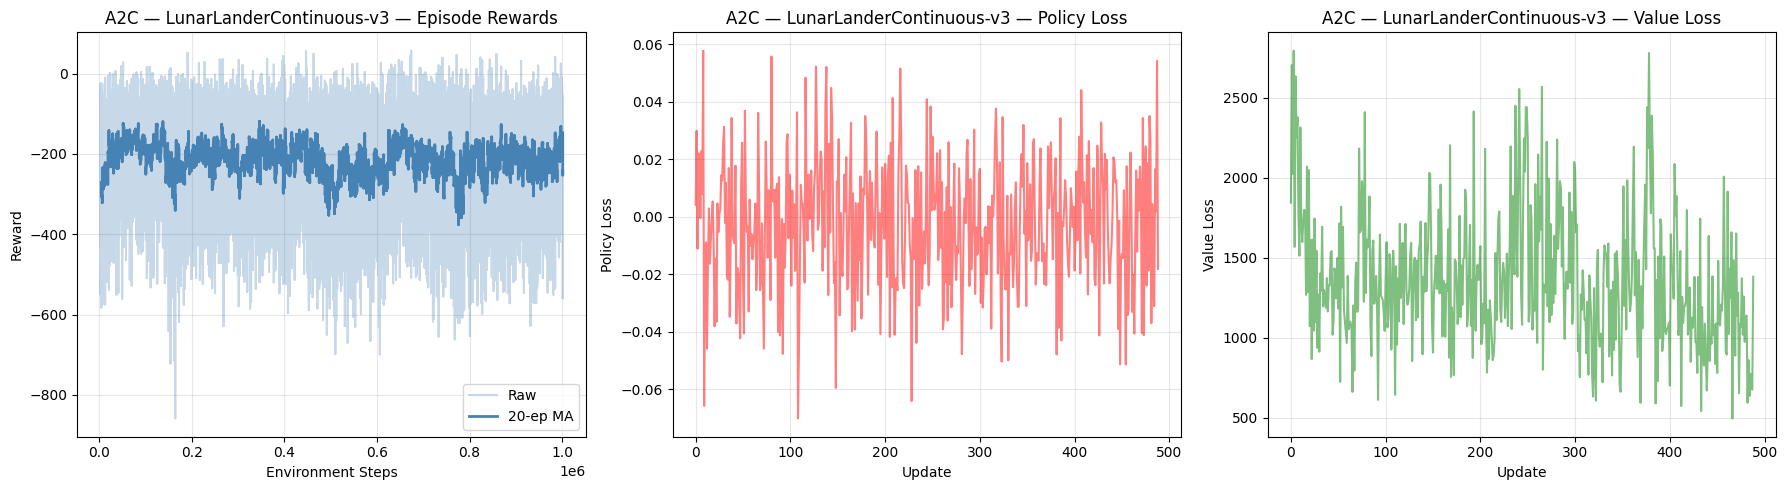

In [16]:
# A.1 — Full A2C run on LunarLanderContinuous-v3
a2c_results = train_a2c(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 1_000_000,
    n_steps         = 2048,
    batch_size      = 64,
    lr              = 3e-4,
    gae_lambda      = 0.95,
    ent_coef        = 0.01,
    seed            = 42,
    solve_threshold = 200.0,
    log_interval    = 10,
)
plot_a2c_results(a2c_results, title="A2C — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

In [17]:
# A.1 — Visualize the trained A2C agent (LunarLanderContinuous-v3)
video_path = record_agent_video(
    a2c_results['agent'],
    env_name     = "LunarLanderContinuous-v3",
    agent_type   = "a2c",
    num_episodes = 3,
    seed         = 0,
    name_prefix  = "a2c_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = -119.1
Episode 2: reward = -152.4
Episode 3: reward = -115.8
Video saved → /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments/videos/a2c_lunar-episode-2.mp4


## A.2 — Train SAC on LunarLanderContinuous-v3

Step    10,000 | Avg Reward (10 ep):  -106.3 | Alpha: 0.3303
Step    20,000 | Avg Reward (10 ep):   -51.3 | Alpha: 0.0614
Step    30,000 | Avg Reward (10 ep):    52.1 | Alpha: 0.0597
Step    40,000 | Avg Reward (10 ep):     8.4 | Alpha: 0.0704
Step    50,000 | Avg Reward (10 ep):    25.5 | Alpha: 0.1044
Step    60,000 | Avg Reward (10 ep):    29.2 | Alpha: 0.0745
Step    70,000 | Avg Reward (10 ep):   159.5 | Alpha: 0.0980
Solved at step 74,610! Avg reward (10 ep): 205.1
Plot saved → /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments/plots/sac__lunarlandercontinuous-v3.png


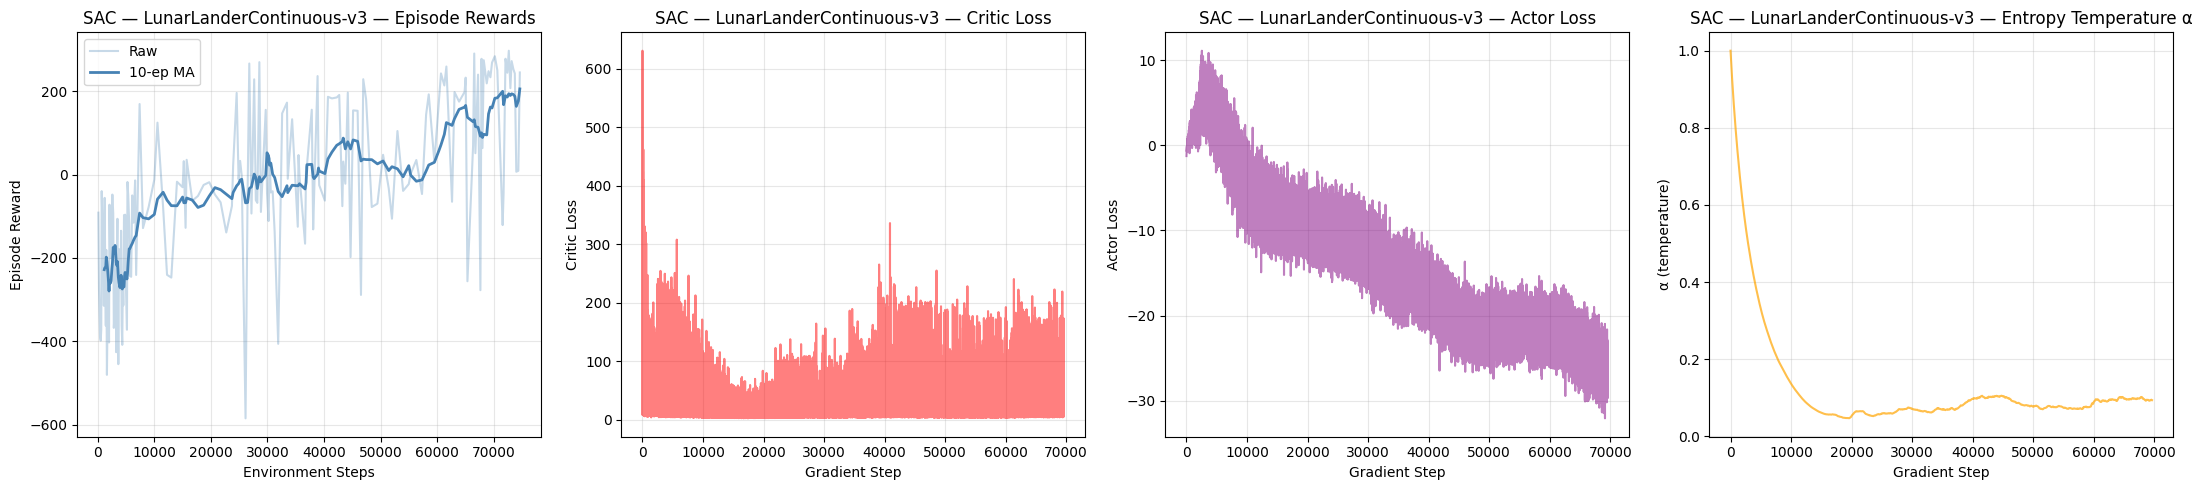

In [18]:
# A.2 — Full SAC run on LunarLanderContinuous-v3
sac_results = train_sac(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 300_000,
    learning_starts = 5000,
    batch_size      = 256,
    lr              = 3e-4,
    tau             = 0.005,
    gamma           = 0.99,
    autotune_alpha  = True,
    seed            = 42,
    solve_threshold = 200.0,
    log_interval    = 10_000,
)
plot_sac_results(sac_results, title="SAC — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

In [19]:
# A.2 — Visualize the trained SAC agent (LunarLanderContinuous-v3)
video_path = record_agent_video(
    sac_results['agent'],
    env_name   = "LunarLanderContinuous-v3",
    agent_type = "sac",
    num_episodes = 3,
    seed         = 0,
    name_prefix  = "sac_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = 247.1
Episode 2: reward = 263.8
Episode 3: reward = 226.4
Video saved → /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments/videos/sac_lunar-episode-2.mp4


---

# Part B — Experiments

---

**For all experiments:** Run at least **3 different random seeds** and report mean ± std.

## B.1 — Ablation: SAC Entropy Temperature

Compare fixed α vs auto-tuned α.

Step     5,000 | Avg Reward (10 ep):  -199.7 | Alpha: 0.0500
Step    10,000 | Avg Reward (10 ep):  -239.3 | Alpha: 0.0500
Step    15,000 | Avg Reward (10 ep):  -106.6 | Alpha: 0.0500
Step    20,000 | Avg Reward (10 ep):   -21.8 | Alpha: 0.0500
Step    25,000 | Avg Reward (10 ep):   -95.7 | Alpha: 0.0500
Step    30,000 | Avg Reward (10 ep):   -94.8 | Alpha: 0.0500
Step    35,000 | Avg Reward (10 ep):  -158.2 | Alpha: 0.0500
Step    40,000 | Avg Reward (10 ep):  -148.5 | Alpha: 0.0500
Step    45,000 | Avg Reward (10 ep):   -72.5 | Alpha: 0.0500
Step    50,000 | Avg Reward (10 ep):    -8.5 | Alpha: 0.0500
Step    55,000 | Avg Reward (10 ep):    -3.7 | Alpha: 0.0500
Step    60,000 | Avg Reward (10 ep):    -8.2 | Alpha: 0.0500
Step    65,000 | Avg Reward (10 ep):     0.3 | Alpha: 0.0500
Step    70,000 | Avg Reward (10 ep):    -3.3 | Alpha: 0.0500
Step    75,000 | Avg Reward (10 ep):   -36.2 | Alpha: 0.0500
Step    80,000 | Avg Reward (10 ep):   -29.1 | Alpha: 0.0500
Step    85,000 | Avg Rew

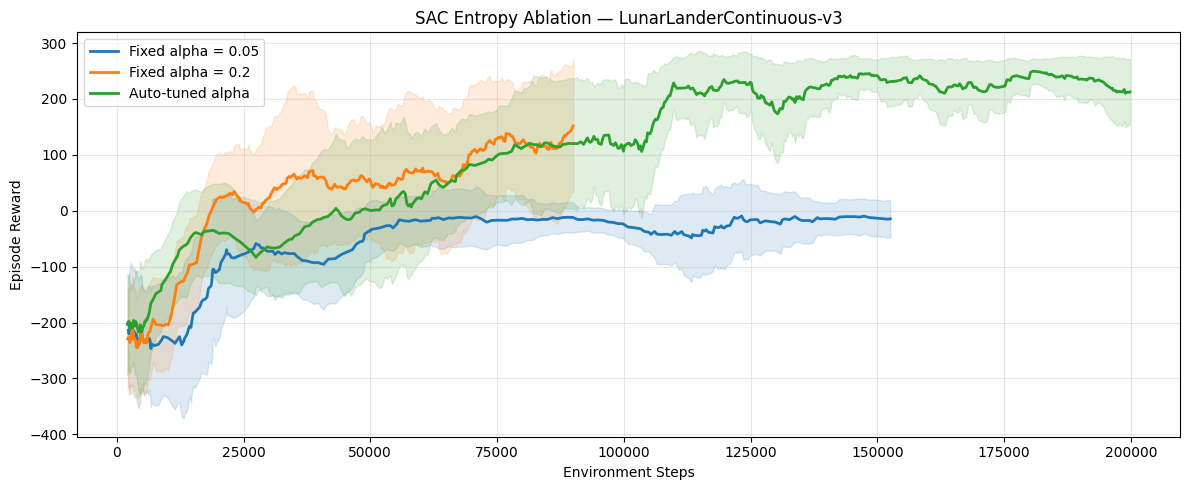


Mean ± Std of average reward (last 20 episodes):
  Fixed alpha = 0.05: 33.4 ± 68.5
  Fixed alpha = 0.2: 158.3 ± 108.5
  Auto-tuned alpha: 213.8 ± 45.4


In [20]:
# B.1 — Ablation: SAC entropy temperature (fixed vs auto-tuned)
seeds = [42, 123, 456]

entropy_results = {
    'Fixed alpha = 0.05': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.05, seed=s,
        )
        for s in seeds
    ],
    'Fixed alpha = 0.2': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.2, seed=s,
        )
        for s in seeds
    ],
    'Auto-tuned alpha': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=True, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(entropy_results, title="SAC Entropy Ablation — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

# Summary statistics
print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in entropy_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

## B.2 — Ablation: GAE Lambda in A2C

Compare λ = 0 (one-step TD), λ = 0.95 (default), and λ = 1.0 (Monte Carlo).

Update   10 | Steps    20,480 | Avg Reward (10 ep):  -267.0 | Policy Loss: -0.0034 | Value Loss: 101.0401
Update   20 | Steps    40,960 | Avg Reward (10 ep):  -206.7 | Policy Loss:  0.0220 | Value Loss: 103.2632
Update   30 | Steps    61,440 | Avg Reward (10 ep):  -258.7 | Policy Loss:  0.0200 | Value Loss: 87.2583
Update   40 | Steps    81,920 | Avg Reward (10 ep):  -226.1 | Policy Loss:  0.0396 | Value Loss: 74.2080
Update   50 | Steps   102,400 | Avg Reward (10 ep):  -214.2 | Policy Loss: -0.0013 | Value Loss: 70.0013
Update   60 | Steps   122,880 | Avg Reward (10 ep):  -255.4 | Policy Loss:  0.0287 | Value Loss: 69.8478
Update   70 | Steps   143,360 | Avg Reward (10 ep):  -316.0 | Policy Loss:  0.0269 | Value Loss: 81.8685
Update   80 | Steps   163,840 | Avg Reward (10 ep):  -198.0 | Policy Loss: -0.0028 | Value Loss: 76.0762
Update   90 | Steps   184,320 | Avg Reward (10 ep):  -330.0 | Policy Loss:  0.0019 | Value Loss: 75.8132
Update  100 | Steps   204,800 | Avg Reward (10 ep):  

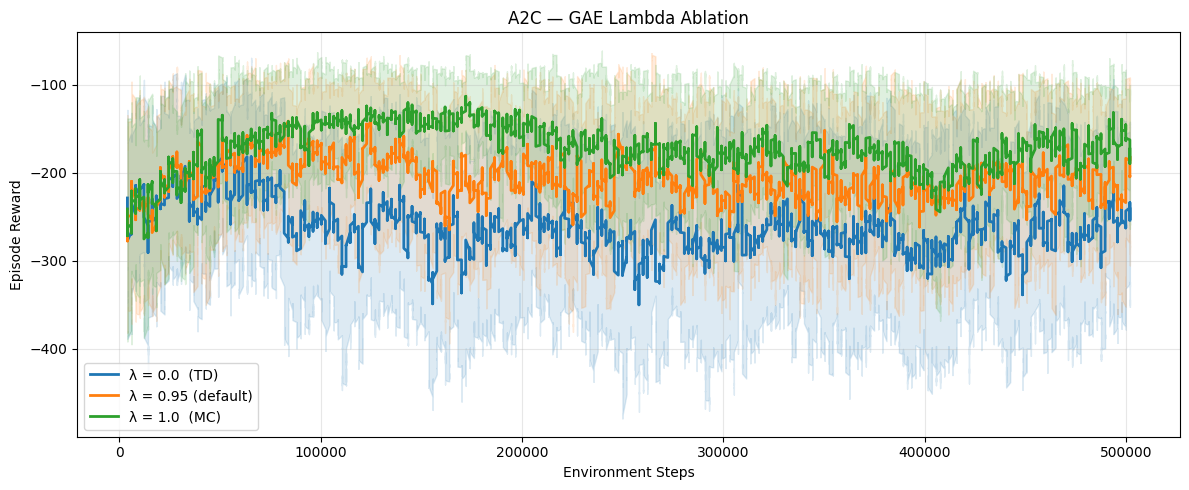


Mean ± Std of average reward (last 20 episodes):
  λ = 0.0  (TD): -254.7 ± 49.3
  λ = 0.95 (default): -209.9 ± 29.1
  λ = 1.0  (MC): -152.8 ± 4.8


In [21]:
# B.2 — Ablation: GAE lambda in A2C
seeds = [42, 123, 456]

lambda_results = {
    'λ = 0.0  (TD)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 0.95 (default)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.95, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 1.0  (MC)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=1.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(lambda_results, title="A2C — GAE Lambda Ablation", experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in lambda_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

---

## Summary

### A.1 — A2C on LunarLanderContinuous-v3

A2C fails to make consistent progress on this task. The reward stays around −150 to −200
throughout 1 M environment steps, with very high variance across episodes. The policy loss
oscillates without a clear downward trend, and the value loss remains large. A2C's
on-policy nature and single gradient step per rollout make it sample-inefficient for
continuous control tasks with sparse, delayed rewards.

---

### A.2 — SAC on LunarLanderContinuous-v3

SAC solves the environment cleanly. The reward rises steadily from ~−200 and crosses +200
by roughly 40k–50k environment steps, then stabilizes above +200. The entropy temperature α
decays from ~0.9 to near zero as the policy becomes more deterministic — a sign that the
agent has found a reliable strategy. Compared to A2C, SAC is dramatically more
sample-efficient thanks to its off-policy replay buffer and twin-Q targets.

---

### B.1 — SAC Entropy Temperature Ablation

| α setting | Final Reward (≈200k steps) | Behaviour |
|-----------|---------------------------|-----------|
| Fixed α = 0.05 | ~−25 to 0 | Under-explores; gets stuck |
| Fixed α = 0.2 | ~100–125 | Improves but plateaus early |
| **Auto-tuned α** | **~225–250** | **Best; adapts entropy throughout training** |

Auto-tuned α is the clear winner. It starts high (encouraging exploration early) and
decays as the policy converges, exploiting the learned strategy without over-committing
to a fixed entropy level. Fixed α = 0.05 is too conservative from the start, preventing
sufficient exploration of the continuous action space.

**Key insight:** Entropy temperature is highly task-dependent. Auto-tuning removes
this hyperparameter and consistently matches or beats the best fixed value.

---

### B.2 — GAE Lambda Ablation (A2C)

| λ | Final Reward (≈500k steps) | Behaviour |
|---|---------------------------|-----------|
| 0.0 (pure TD) | ~−200 to −250 | Steady but slow; high bootstrap bias |
| **0.95 (default)** | **~−150 to −200** | **Marginally best; balanced bias-variance** |
| 1.0 (Monte Carlo) | ~−250 to −300 | Highest variance; slowest improvement |

All three variants fail to solve LunarLanderContinuous — this confirms that A2C's
fundamental sample inefficiency is the bottleneck, not the GAE parameter. λ = 0.95
performs marginally better, consistent with it being the standard default, but the
differences are small relative to the inter-seed variance.

**Key insight:** GAE lambda matters most when the base algorithm is already learning.
When the algorithm struggles fundamentally (as A2C does here), tuning λ has limited impact.
This motivates switching to an off-policy method (SAC) rather than tuning A2C further.


---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**
